In [1]:
%load_ext autoreload
%autoreload 2

In [8]:
import os
import torch
import mdtraj as md
import numpy as np
from tqdm import tqdm
from pathlib import Path
from datasets.dataset_utils_empty import Molecules, DEShawDataset, AtomSelection, to_angstrom
from models.graph_transformer import GraphTransformer
from evaluate.evaluators import TicEvaluator
from evaluate.msm_utils import discretize_trajectory
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def plot_losses(
    train_losses: np.ndarray, test_losses: np.ndarray, title: str
) -> None:
    plt.figure()
    n_epochs = len(test_losses) - 1
    x_train = np.linspace(0, n_epochs, len(train_losses))
    x_test = np.arange(n_epochs + 1)

    plt.plot(x_train, train_losses, label="train loss")
    plt.plot(x_test, test_losses, label="test loss")
    plt.legend()
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.yscale("log")

device = torch.device(torch.cuda.current_device())


protein_name = "chignolin"
gen_mode = "langevin" # Mode of generation, "iid" or "langevin"
subsample = None # Give integer if only a random subset of the samples should be analyzed (if None, all samples are used)
append_exp_name = None # Append string to the experiment name"
append_exp_name_str = '_' + append_exp_name if append_exp_name else ''
eval_folder = f"./saved_models/{protein_name}/main_eval_output_{gen_mode}{append_exp_name_str}"

cluster_endpoints_path = Path(
        os.path.join(
            "evaluate",
            "saved_references",
            f"saved_cluster_endpoints_{protein_name.upper()}.npy",
        )
    )

clusters = np.load(cluster_endpoints_path)
start, end =  clusters[0], clusters[1]
pdb_file = f"./datasets/folded_pdbs/{Molecules[protein_name.upper()].value}-0-c-alpha.pdb"

# Load samples from the ground truth simulations to serve as training data
dataset = DEShawDataset(
    data_root="/data/sanjeevr/Reference_MD_Sims",
    molecule=Molecules[protein_name.upper()],
    simulation_id=0,
    atom_selection=AtomSelection.A_CARBON,
    return_bond_graph=False,
    transform=to_angstrom,
    align=False,
)

gt_traj = 10 * torch.tensor(dataset.traj.xyz)  # convert to angstroms
gt_traj -= gt_traj.mean(1, keepdims=True)  # center


if subsample is not None:
    gt_traj = gt_traj[np.random.permutation(subsample)]
# print(f"Size of samples set (num_samples x num_backbone_atoms x 3): {sampled_mol.shape}")
n_atoms = gt_traj.shape[1]

# Load topology from pdb file
topology = md.load(pdb_file).topology

# Load cluster centers
cluster_centers_path = Path(
    os.path.join(
        "evaluate",
        "saved_references",
        f"saved_cluster_centers_{protein_name.upper()}.npy",
    )
)
cluster_coords = np.load(cluster_centers_path)

iid_sample_path = Path(os.path.join(os.path.dirname(eval_folder), "main_eval_output_iid"))
# Get TICA
tic_evaluator = TicEvaluator(
    val_data=None,
    mol_name=protein_name,
    eval_folder=iid_sample_path,
    data_folder="datasets",
    folded_pdb_folder="datasets/folded_pdbs",
    bins=101,
    evalset="testset",
)
# assign cluster centers to the iid samples
cluster_assignments = torch.tensor(discretize_trajectory(
    gt_traj, tic_evaluator, cluster_coords
))

/home/sanjeevr/om-diffusion/two-for-one-diffusion/evaluate/msm_utils.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(xyz), tic_evaluator.folded


In [27]:
# trainset, _, _ = get_dataset(
#         args.mol,
#         args.mean0,
#         args.data_folder,
#         args.fold,
#         shuffle_before_splitting=args.shuffle_data_before_splitting,
#     )

model = GraphTransformer(num_beads = n_atoms, hidden_nf=64, conservative=True).to(device)

# add sigmoid activation to the output
class CommittorNN(torch.nn.Module):
    def __init__(self, model):
        super(CommittorNN, self).__init__()
        self.model = model
        self.sigmoid = torch.nn.Sigmoid()
    def forward(self, x, h, t):
        committor_prob = self.sigmoid(self.model(x, h, t, return_energy = True).sum(dim = (-2, -1)))
        return committor_prob


committor_model = CommittorNN(model)

# Train the model on the sampled molecules
optimizer = torch.optim.Adam(committor_model.parameters(), lr=3e-4)
batch_size = 256
n_epochs = 20
max_data_size = 10000

train_losses = []
test_losses = []

# split sampled_mol and cluster_assignments into train test sets
gt_traj = gt_traj[:max_data_size]
cluster_assignments = cluster_assignments[:max_data_size]
x_train, x_test, cluster_train, cluster_test = train_test_split(gt_traj, cluster_assignments, test_size=0.2)


trainset = torch.utils.data.TensorDataset(x_train, cluster_train)
train_dataloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

testset = torch.utils.data.TensorDataset(x_test, cluster_test)
test_dataloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=True)

for _ in tqdm(range(n_epochs)):
    committor_model.train()
    for x, cluster in train_dataloader:
        
        optimizer.zero_grad()
        x = x.to(device).requires_grad_(True)
        cluster = cluster.to(device)
        start_mask = cluster == start
        end_mask = cluster == end
        transition_mask = torch.logical_and(~start_mask, ~end_mask)
        h = torch.eye(n_atoms).to(device)
        t = torch.zeros((x.shape[0], )).to(device)
        prob = committor_model(x, h, t)
        grad_prob = torch.autograd.grad(
            outputs=prob,  # [batch_size, ]
            inputs=x,  # [batch_size, n_nodes, 3]
            grad_outputs=torch.ones_like(prob),
            retain_graph=True,  # Make sure the graph is not destroyed during training
            create_graph=True,  # Create graph for second derivative
            allow_unused=True,
            )[0]
        grad_loss = 0
        start_boundary_loss = 0
        end_boundary_loss = 0

        if transition_mask.sum() > 0:
            grad_loss = torch.norm(grad_prob, dim=(-2, -1)).mean()#[transition_mask].mean()
        if start_mask.sum() > 0:
            start_boundary_loss = (prob**2)[start_mask].mean()
        if end_mask.sum() > 0:
            end_boundary_loss = ((1 - prob)**2)[end_mask].mean()

        loss = grad_loss + start_boundary_loss + end_boundary_loss

        loss.backward()
        optimizer.step()
        train_losses.append(loss.detach().unsqueeze(-1))
        
    # Test the model on the test set
    committor_model.eval()
    tls = []
    for x, cluster in test_dataloader:
        x = x.to(device).requires_grad_(True)
        cluster = cluster.to(device)
        start_mask = cluster == start
        end_mask = cluster == end
        transition_mask = torch.logical_and(~start_mask, ~end_mask)
        h = torch.eye(n_atoms).to(device)
        t = torch.zeros((x.shape[0], )).to(device)
        prob = committor_model(x, h, t)
        grad_prob = torch.autograd.grad(
            outputs=prob,  # [batch_size, ]
            inputs=x,  # [batch_size, n_nodes, 3]
            grad_outputs=torch.ones_like(prob),
            retain_graph=True,  # Make sure the graph is not destroyed during training
            create_graph=True,  # Create graph for second derivative
            allow_unused=True,
            )[0]
        grad_loss = 0
        start_boundary_loss = 0
        end_boundary_loss = 0

        if transition_mask.sum() > 0:
            grad_loss = torch.norm(grad_prob, dim=(-2, -1)).mean()#[transition_mask].mean()
        if start_mask.sum() > 0:
            start_boundary_loss = (prob**2)[start_mask].mean()
        if end_mask.sum() > 0:
            end_boundary_loss = ((1 - prob)**2)[end_mask].mean()

        loss = grad_loss + start_boundary_loss + end_boundary_loss
        tls.append(loss.detach().unsqueeze(-1))
    
    test_loss = torch.cat(tls).sum(0) / len(tls)
    test_losses.append(test_loss.unsqueeze(-1))


train_losses = torch.cat(train_losses).cpu().numpy()
test_losses = torch.cat(test_losses).cpu().numpy()


100%|██████████| 20/20 [00:19<00:00,  1.01it/s]


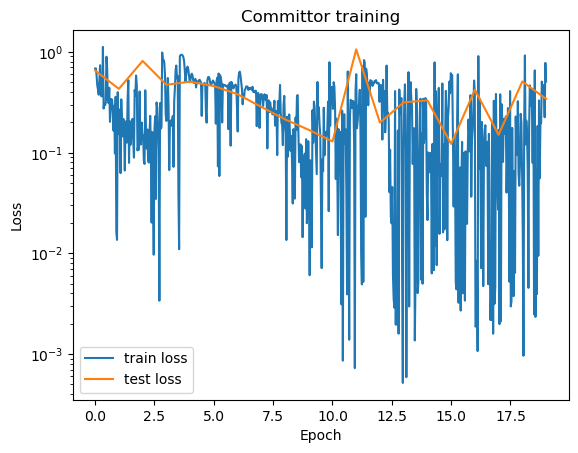

In [28]:
plot_losses(train_losses, test_losses, "Committor training")

Text(0.5, 1.0, 'Committor Probability on TICA plot')

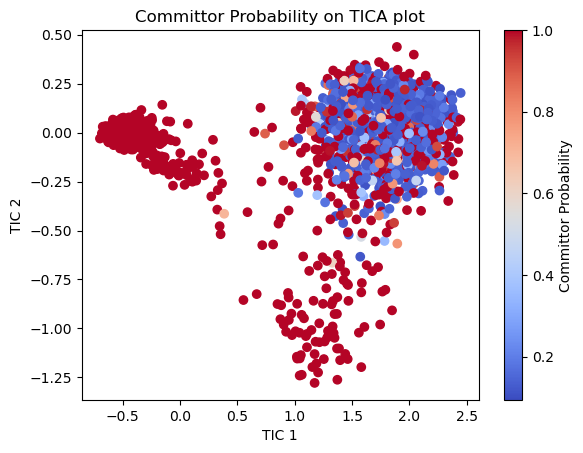

In [33]:
# create a TIC plot of the ground truth data and color by predicted committor probability
committor_model.eval()

# Get committor probabilities for the ground truth data
committor_probs = []
xs = []
for x, cluster in train_dataloader:
    x = x.to(device).requires_grad_(True)
    cluster = cluster.to(device)
    h = torch.eye(n_atoms).to(device)
    t = torch.zeros((x.shape[0], )).to(device)
    prob = committor_model(x, h, t)
    committor_probs.append(prob)
    xs.append(x)

committor_probs = torch.cat(committor_probs).cpu().detach().numpy()
xs = torch.cat(xs).cpu().detach().numpy()


# Get TICA for the ground truth data
sample_tic_features = tic_evaluator.get_tic_features(
        torch.tensor(xs), tic_evaluator.folded
    )
transformed_samples = tic_evaluator.tica(sample_tic_features)

# Plot the TICA plot
plt.figure()
scatter = plt.scatter(transformed_samples[:, 0], transformed_samples[:, 1], c=committor_probs, cmap='coolwarm')
plt.colorbar(scatter, label='Committor Probability')
plt.xlabel('TIC 1')
plt.ylabel('TIC 2')
plt.title('Committor Probability on TICA plot')


# Plot the cluster centers
# plt.scatter(cluster_coords[start, 0], cluster_coords[start, 1], c='green', s=50, marker='x')
# plt.scatter(cluster_coords[end, 0], cluster_coords[end, 1], c='red', s=50, marker='x')